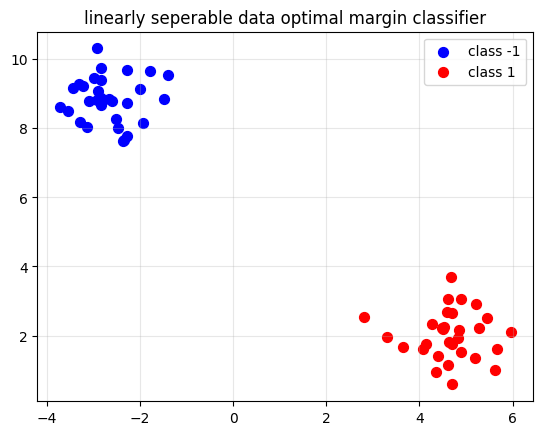

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

np.random.seed(42)

X,Y= make_blobs(n_samples=60,centers=2,random_state=42,cluster_std=0.7)
Y=np.where(Y==0,-1,1)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

plt.scatter(X[Y==-1][:,0],X[Y==-1][:,1],color='blue',s=50,label='class -1')
plt.scatter(X[Y==1][:,0],X[Y==1][:,1],color='red',s=50,label='class 1')
plt.title("linearly seperable data optimal margin classifier")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [3]:
from scipy.optimize import minimize
m= len(X_train)

K=X_train@X_train.T

def dual_objectives(alphas):
    #sum of alphas-1/2double sigma(alphaialphajyiyjxixj)
    #vector form
    yy=np.outer(Y_train,Y_train)
    return 0.5*alphas@(yy*K)@alphas-np.sum(alphas)

def dual_gradient(alphas):
    yy=np.outer(Y_train,Y_train)
    return  (yy*K)@alphas-np.ones(m)

constraints={
    'type':'eq',
    'fun': lambda a:np.dot(a,Y_train),
    'jac':lambda a:Y_train
}
bounds=[(0,None)]*m

alpha_innit=np.zeros(m)
result=minimize(dual_objectives,alpha_innit,jac=dual_gradient,method='SLSQP',bounds=bounds,constraints=constraints,options={'ftol':1e-9,'maxiter':1000})

alphas=result.x

print(f"optimisation successful: {result.success}")
print(f"number of alphas>0(support vectors): {(alphas>1e-4).sum()}/{m}")

optimisation successful: True
number of alphas>0(support vectors): 2/48


In [4]:
sv_mask=alphas>1e-4
sv_alphas=alphas[sv_mask]
sv_X=X_train[sv_mask]
sv_Y=Y_train[sv_mask]

print(f"Support vectors: {sv_mask.sum()}")

w=np.sum(sv_alphas[:,None]*sv_Y[:,None]*sv_X,axis=0)
print(f"w dual: {w.round(4)}")

b_values=sv_Y-sv_X@w
b=np.mean(b_values)
print(f"b(dual): {b:.4f}")

def predict_dual(X_new,w,b):
    return np.sign(X_new@w+b)

y_pred_dual=predict_dual(X_test,w,b)

sklearn_svm=SVC(kernel='linear',C=1e6)
sklearn_svm.fit(X_train, Y_train)
y_pred_sk=sklearn_svm.predict(X_test)

print("Dual SVM accuracy: ",accuracy_score(Y_test,y_pred_dual))
print("Sklearn SVM accuracy: ",accuracy_score(Y_test,y_pred_sk))



Support vectors: 2
w dual: [ 0.1963 -0.1934]
b(dual): 0.9422
Dual SVM accuracy:  1.0
Sklearn SVM accuracy:  1.0


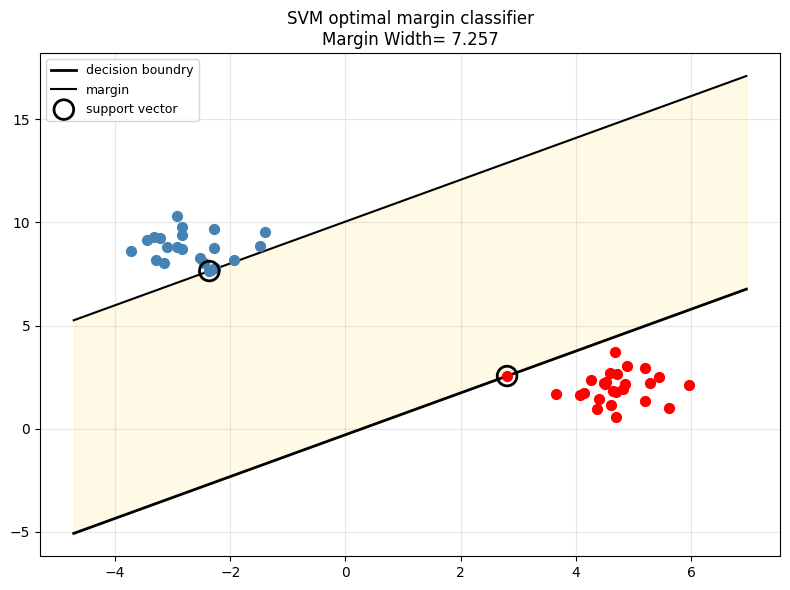

In [5]:
def plot_svm_margin(X,y,w,b,sv_X, title):
    fig,ax = plt.subplots(figsize=(8,6))

    ax.scatter(X[y==-1][:,0],X[y==-1][:,1],color='steelblue',s=50,zorder=3)
    ax.scatter(X[y==1][:,0],X[y==1][:,1],color='red',s=50,zorder=3)

    X1=np.linspace(X[:,0].min()-1,X[:,0].max()+1,300)
    ax.plot(X1,-((w[0]*X1+b-1)/w[1]),'k-',lw=2,label='decision boundry')
    ax.plot(X1,-((w[0]*X1+b+1)/w[1]),'k-',lw=1.5,label='margin')

    ax.fill_between(X1,-((w[0]*X1+b-1)/w[1]),-((w[0]*X1+b+1)/w[1]),alpha=0.1,color='gold')

    #circling support vectos
    ax.scatter(sv_X[:,0],sv_X[:,1],s=200,facecolors='none',edgecolors='black',linewidths=2,zorder=4,label='support vector')

    margin_width=2/np.linalg.norm(w)
    ax.set_title(f"{title}\nMargin Width= {margin_width:.3f}")
    ax.legend(fontsize=9);ax.grid(alpha=0.3)
    plt.tight_layout();plt.show()

plot_svm_margin(X_train,Y_train,w,b,sv_X,"SVM optimal margin classifier")

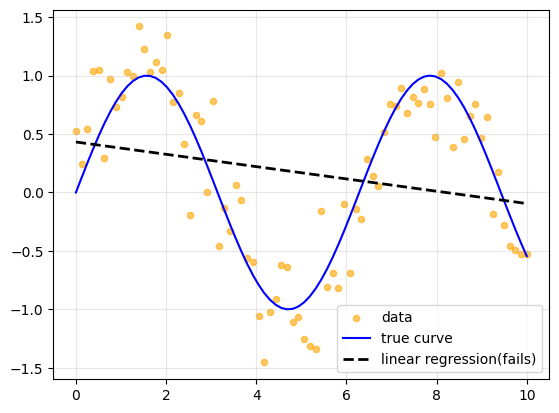

In [6]:
np.random.seed(0)
X_reg=np.linspace(0,10,80).reshape(-1,1)
Y_reg=np.sin(X_reg).ravel()+0.3*np.random.randn(80)

from  sklearn.linear_model import LinearRegression,Ridge

lr_reg=LinearRegression().fit(X_reg,Y_reg)
Y_lr=lr_reg.predict(X_reg)

plt.scatter(X_reg,Y_reg,s=20,color='orange',alpha=0.6,label='data')
plt.plot(X_reg,np.sin(X_reg),color='blue',lw=1.5,label='true curve')
plt.plot(X_reg,Y_lr,color='black',lw=2,linestyle='--',label='linear regression(fails)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [7]:
def kernel_linear(X1,X2):
    return X1@X2.T

def kernel_polynomial(X1,X2,degree=3,c=1):
    return(X1@X2.T+c)**degree

def kernel_rbf(X1,X2,sigma=1.0):
    X1_sq=np.sum(X1**2,axis=1,keepdims=True)
    X2_sq=np.sum(X2**2,axis=1,keepdims=True)
    sq_dists=X1_sq+X2_sq.T-2*X1@X2.T
    return np.exp(-sq_dists/(2*sigma*sigma))

x_demo=np.array([[1.0],[2.0],[3.0]])
print(x_demo.shape)
print("Kernel matrix (linear):")
print(kernel_linear(x_demo, x_demo).round(3))
print("\nKernel matrix (RBF σ=1):")
print(kernel_rbf(x_demo, x_demo, sigma=1.0).round(3))

(3, 1)
Kernel matrix (linear):
[[1. 2. 3.]
 [2. 4. 6.]
 [3. 6. 9.]]

Kernel matrix (RBF σ=1):
[[1.    0.607 0.135]
 [0.607 1.    0.607]
 [0.135 0.607 1.   ]]


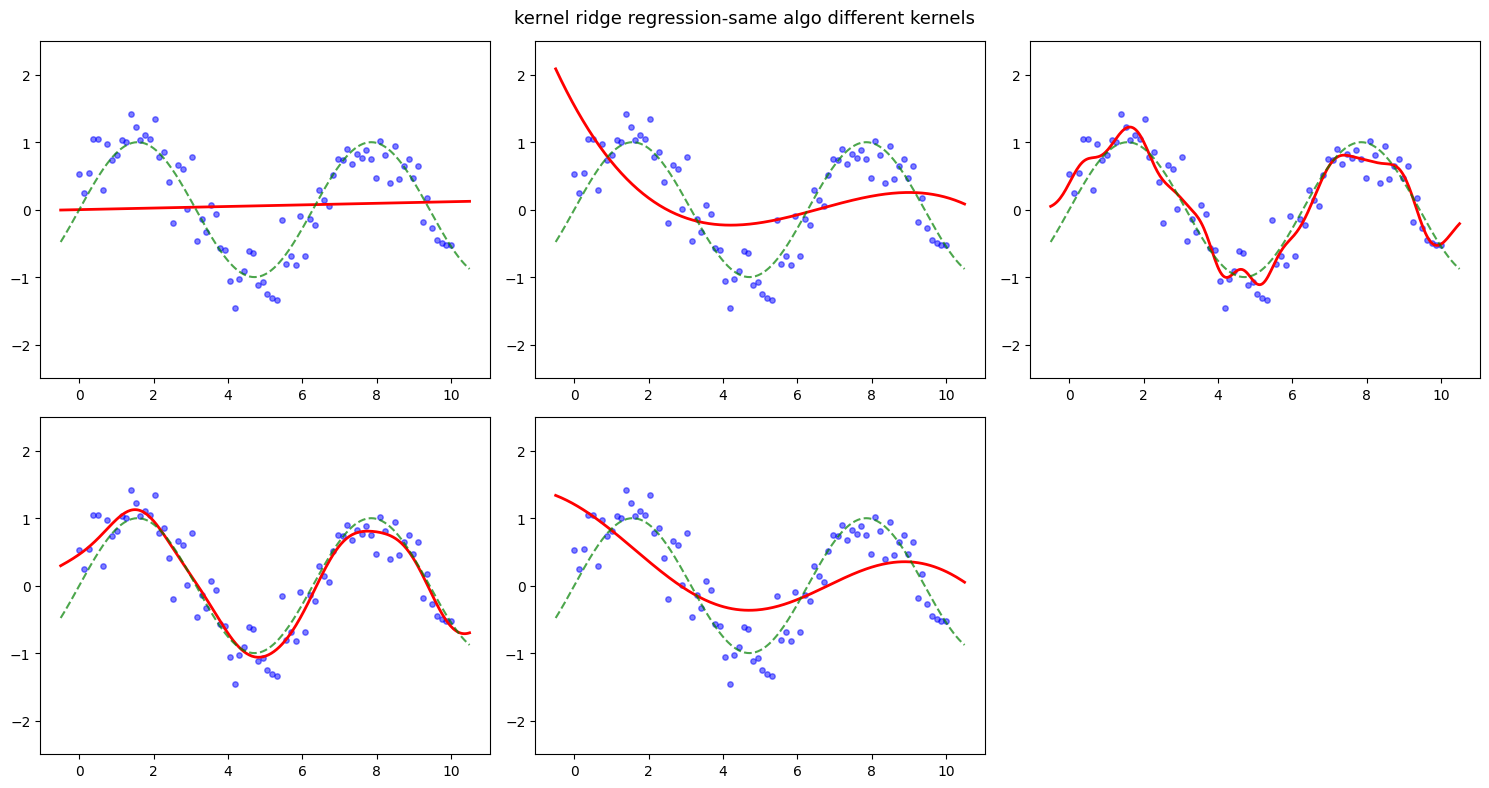

In [12]:
class KernelRidgeRegression:
    def __init__(self,kernel_fn,lambda_=0.1):
        self.kernel_fn=kernel_fn
        self.lambda_ =lambda_
    
    def fit(self,X,y):
        self.X_train=X
        m=len(X)

        K=self.kernel_fn(X,X)

        self.alpha=np.linalg.solve(K+self.lambda_*np.eye(m),y)
        return self
    
    def predict(self,X_new):
        K_new=self.kernel_fn(X_new,self.X_train)
        return K_new@self.alpha
    
X_plot=np.linspace(-0.5,10.5,300).reshape(-1,1)
models={'Linear Kernel': KernelRidgeRegression(kernel_linear,lambda_=0.1),
        'Polynomial (degree=3)':KernelRidgeRegression(lambda X1,X2:kernel_polynomial(X1,X2,degree=3),lambda_=0.1),
        'RBF sigma=0.5':KernelRidgeRegression(lambda X1,X2:kernel_rbf(X1,X2,sigma=0.5),lambda_=0.1),
        'RBF sigma=1':KernelRidgeRegression(lambda X1,X2:kernel_rbf(X1,X2,sigma=1.00),lambda_=0.1),
        'RBF sigma=5':KernelRidgeRegression(lambda X1,X2:kernel_rbf(X1,X2,sigma=5.0),lambda_=0.1)
        }
for name,model in models.items():
    model.fit(X_reg,Y_reg)

fig,axes=plt.subplots(2,3,figsize=(15,8))
axes=axes.ravel()

for i,(names,model) in enumerate(models.items()):
    y_plot=model.predict(X_plot)
    axes[i].scatter(X_reg,Y_reg,s=15,color='blue',alpha=0.5)
    axes[i].plot(X_plot,y_plot,color='red',lw=2)
    axes[i].plot(X_plot,np.sin(X_plot),color='green',lw=1.5,linestyle='--',alpha=0.7)
    axes[i].set_ylim(-2.5,2.5)

axes[5].axis('off')
plt.suptitle("kernel ridge regression-same algo different kernels",fontsize=13)
plt.tight_layout()
plt.show()

kernel svm with smo algo

In [ ]:
class SMO:
    def __innit__(self,kernel_fn,C=1.0,tol=1e-3,max_passes=50):
        self.kernel_fn=kernel_fn
        self.C=C
        self.max_passes=max_passes
    

    def fit(Self,X,y):
        m=len(y)
        self.X_train=X
        self.y_train=y

        self.K=self.kernel_fn(X,X)

        self.alphas=np.zeros(m)
        self.b=0.0
        self.m=m

        passes=0
        iteration=0

        while(passes<=self.max_passes):
            num_changed=0

            for i in range(0,m):

                f_i=(self.alphas*y)@self.K[:,i]+self.b
                E_i=f_i-y[i]

                kkt_violated=(
                    (y[i]*E_i<-self.tol and self.alphas[i]<self.C) or
                    (y[i]*E_i>self.tol and self.alphas[i]>0)
                )
                if not kkt_violated:
                    continue

                j=i
                while(j==i):
                    j=np.random.randint(0,m)
                
                f_j=(self.alphas*y)@self.K[:,j]+self.b
                E_j=f_j-y[j]

                if y[i]!=y[j]:
                    L=max(0,self.alphas[j]-self.alphas[i])
                    H=min(self.C,self.C+self.alphas[j]-self.alphas[i])

                else:
                    L=max(0,self.alphas[i]+self.alphas[j]-self.C)
                    H=min(self.C,self.alphas[i]+self.alphas[j])

                if L>=H:
                    continue
                